In [1]:
print("hello vs")

hello vs


In [2]:
marks = [23, 45,32,25,26,28,29,30,31,32]
print(marks[2:3])
print(marks[ : 3])
print(marks[ :-3])
print(marks[3:])
print(marks[-3:])


[32]
[23, 45, 32]
[23, 45, 32, 25, 26, 28, 29]
[25, 26, 28, 29, 30, 31, 32]
[30, 31, 32]


In [3]:
import pandas as pd

data = {
    "time": [1, 2, 3, 4, 5],
    "bid_price": [142.04, 142.04, 142.05, 142.05, 142.04],
    "ask_price": [142.05, 142.05, 142.06, 142.06, 142.05],
    "bid_size": [800, 1200, 600, 400, 700],
    "ask_size": [400, 300, 900, 1100, 700],
}

df = pd.DataFrame(data)
print(df)

   time  bid_price  ask_price  bid_size  ask_size
0     1     142.04     142.05       800       400
1     2     142.04     142.05      1200       300
2     3     142.05     142.06       600       900
3     4     142.05     142.06       400      1100
4     5     142.04     142.05       700       700


In [4]:
df.head()           # first 5 rows
df.head(10)         # first 10 rows
df.tail()           # last 5 rows
df.shape            # (rows, columns) → (5, 5)
df.columns          # list of column names
df.dtypes           # type of each column (int, float, etc.)
df.info()           # everything at once: shape, types, memory
df.describe()       # statistics for each numeric column (mean, std, min, max)

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       5 non-null      int64  
 1   bid_price  5 non-null      float64
 2   ask_price  5 non-null      float64
 3   bid_size   5 non-null      int64  
 4   ask_size   5 non-null      int64  
dtypes: float64(2), int64(3)
memory usage: 332.0 bytes


,time,bid_price,ask_price,bid_size,ask_size
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3.000000,142.044000,142.054000,740.000000,680.000000
std,1.581139,0.005477,0.005477,296.647939,334.664011
min,1.000000,142.040000,142.050000,400.000000,300.000000
25%,2.000000,142.040000,142.050000,600.000000,400.000000
50%,3.000000,142.040000,142.050000,700.000000,700.000000
75%,4.000000,142.050000,142.060000,800.000000,900.000000
max,5.000000,142.050000,142.060000,1200.000000,1100.000000


In [5]:
          # returns the column as a "Series" (1D)
df[["bid_price", "ask_price"]]

,bid_price,ask_price
0,142.04,142.05
1,142.04,142.05
2,142.05,142.06
3,142.05,142.06
4,142.04,142.05


In [6]:
# df.iloc[0]      # first row
# df.iloc[2]      # third row
# df.iloc[-1]     # last row
df.iloc[0:3]    # first 3 rows

,time,bid_price,ask_price,bid_size,ask_size
0,1,142.04,142.05,800,400
1,2,142.04,142.05,1200,300
2,3,142.05,142.06,600,900


In [7]:
# All snapshots where bid_size > 700
# df[df["bid_size"] > 700]

# All snapshots where bid_size > ask_size (buyer pressure)
# df[df["bid_size"] > df["ask_size"]]

# # Multiple conditions (use & and |, not 'and'/'or' — surround each with parentheses)
df[(df["bid_size"] > 500) & (df["ask_size"] < 1000)]

,time,bid_price,ask_price,bid_size,ask_size
0,1,142.04,142.05,800,400
1,2,142.04,142.05,1200,300
2,3,142.05,142.06,600,900
4,5,142.04,142.05,700,700


In [8]:
# python# Create a mid_price column from bid_price and ask_price
df["mid_price"] = (df["bid_price"] + df["ask_price"]) / 2

# Create a spread column
df["spread"] = df["ask_price"] - df["bid_price"]

# Create the OFI column — the famous one
df["ofi"] = (df["bid_size"] - df["ask_size"]) / (df["bid_size"] + df["ask_size"])


In [9]:
df["pressure"] = "Neutral"   # set everything to Neutral first
df.loc[df["ofi"] > 0.1, "pressure"] = "Buy"
df.loc[df["ofi"] < -0.1, "pressure"] = "Sell"
print(df)

   time  bid_price  ask_price  bid_size  ask_size  mid_price  spread  \
0     1     142.04     142.05       800       400    142.045    0.01   
1     2     142.04     142.05      1200       300    142.045    0.01   
2     3     142.05     142.06       600       900    142.055    0.01   
3     4     142.05     142.06       400      1100    142.055    0.01   
4     5     142.04     142.05       700       700    142.045    0.01   

        ofi pressure  
0  0.333333      Buy  
1  0.600000      Buy  
2 -0.200000     Sell  
3 -0.466667     Sell  
4  0.000000  Neutral  


In [10]:
df["future_mid"] = df["mid_price"].shift(-1)   # move column up by 1 row
df["past_mid"] = df["mid_price"].shift(1)      # move column down by 1 row
print(df[["time", "mid_price", "past_mid", "future_mid"]])

   time  mid_price  past_mid  future_mid
0     1    142.045       NaN     142.045
1     2    142.045   142.045     142.055
2     3    142.055   142.045     142.055
3     4    142.055   142.055     142.045
4     5    142.045   142.055         NaN


In [11]:
df["price_change"] = df["future_mid"] - df["mid_price"]

# Label: +1 = price will go up, -1 = down, 0 = flat
df["label"] = 0
df.loc[df["price_change"] > 0, "label"] = 1
df.loc[df["price_change"] < 0, "label"] = -1

print(df[["time", "mid_price", "future_mid", "price_change", "label"]])

   time  mid_price  future_mid  price_change  label
0     1    142.045     142.045          0.00      0
1     2    142.045     142.055          0.01      1
2     3    142.055     142.055          0.00      0
3     4    142.055     142.045         -0.01     -1
4     5    142.045         NaN           NaN      0


In [14]:
import matplotlib.pyplot as plt

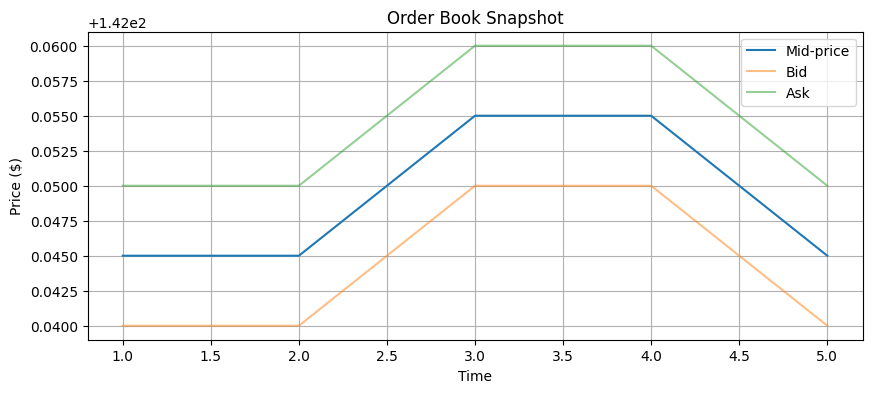

In [15]:
# Recreate the small DataFrame from Day 4import matplotlib.pyplot as plt
data = {
    "time": [1, 2, 3, 4, 5],
    "bid_price": [142.04, 142.04, 142.05, 142.05, 142.04],
    "ask_price": [142.05, 142.05, 142.06, 142.06, 142.05],
}
df = pd.DataFrame(data)
df["mid_price"] = (df["bid_price"] + df["ask_price"]) / 2

plt.figure(figsize=(10, 4))
plt.plot(df["time"], df["mid_price"], label="Mid-price")
plt.plot(df["time"], df["bid_price"], label="Bid", alpha=0.5)   # alpha = transparency
plt.plot(df["time"], df["ask_price"], label="Ask", alpha=0.5)
plt.title("Order Book Snapshot")
plt.xlabel("Time")
plt.ylabel("Price ($)")
plt.legend()                # shows the labels in a box
plt.grid(True)
plt.show()

In [17]:
import numpy as np

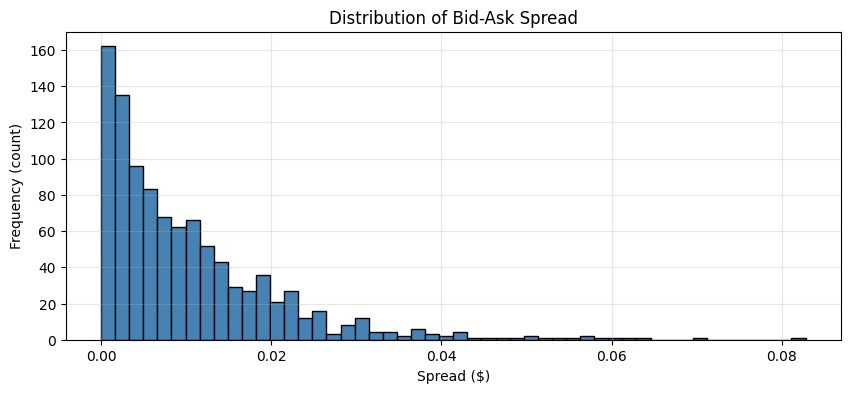

In [18]:
# Generate 1000 random spread values that look realistic
spreads = np.random.exponential(0.01, 1000)   # exponential distribution

plt.figure(figsize=(10, 4))
plt.hist(spreads, bins=50, color="steelblue", edgecolor="black")
plt.title("Distribution of Bid-Ask Spread")
plt.xlabel("Spread ($)")
plt.ylabel("Frequency (count)")
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Generate 50 fake LOB snapshots that look like real Apple stock
n = 50

# Mid-price doing a random walk around $142
mid_price = 142.0 + np.random.randn(n).cumsum() * 0.02

# Bid-ask spread between 0.01 and 0.04
spread = np.random.uniform(0.01, 0.04, n)

# Bid/Ask sizes with some imbalance pattern
bid_size = np.random.randint(200, 1500, n)
ask_size = np.random.randint(200, 1500, n)

# Assemble into a DataFrame
df = pd.DataFrame({
    "time": range(1, n + 1),
    "bid_price": (mid_price - spread / 2).round(2),
    "ask_price": (mid_price + spread / 2).round(2),
    "bid_size": bid_size,
    "ask_size": ask_size,
})

df.head()

,time,bid_price,ask_price,bid_size,ask_size
0,1,142.01,142.02,1159,1250
1,2,141.97,142.01,1205,747
2,3,142.02,142.03,529,1222
3,4,142.05,142.07,334,676
4,5,142.05,142.07,1115,232


In [ ]:
# The 5 essentials on every plot
plt.figure(figsize=(10, 4))    # set size first
plt.plot(x, y)                 # or plt.hist, plt.bar, plt.barh
plt.title("...")
plt.xlabel("...")
plt.ylabel("...")
plt.grid(True, alpha=0.3)
plt.savefig("name.png", dpi=150, bbox_inches="tight")
plt.show()